In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
group_num = '1238'

scores = f'/home/gridsan/akolodziej/ECOD_2/ECOD_results/group_{group_num}/group_{group_num}_all_scores.npz'
data = np.load(scores)

In [29]:
df = pd.DataFrame({
    'struct1': data['struct1'],
    'struct2': data['struct2'],
    'progres': data['progres'],
    'cirpin': data['cirpin'],
})

# Get ecod name
group_file = f'/home/gridsan/akolodziej/ECOD_2/h_groups/group_{group_num}.txt'

with open(group_file, "r") as f:
    first_line = f.readline().strip()
ecod_name = first_line.split('\t')[3]

In [30]:
# Sample up to 10,000 points
df_plot = df.sample(n=min(10_000, len(df)), random_state=42)

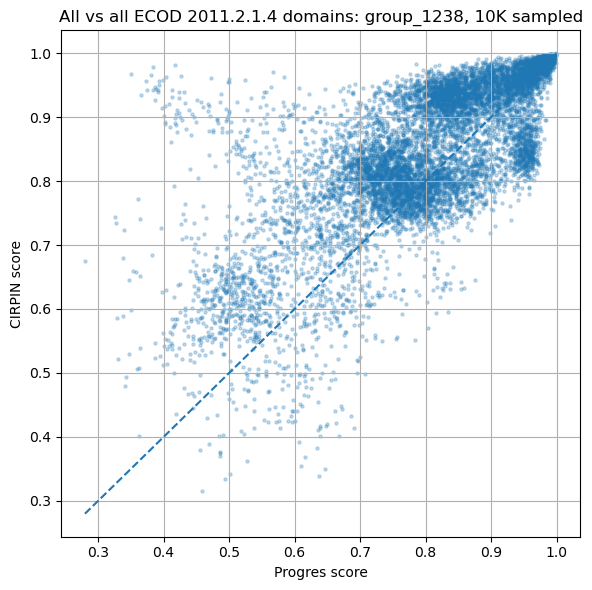

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(df_plot['progres'], df_plot['cirpin'], s=5, alpha=0.25)

plt.xlabel('Progres score')
plt.ylabel('CIRPIN score')
plt.title(f'All vs all ECOD {ecod_name} domains: group_{group_num}, 10K sampled')
plt.grid(True)

# Identity line
mn = min(df_plot['progres'].min(), df_plot['cirpin'].min())
mx = max(df_plot['progres'].max(), df_plot['cirpin'].max())
plt.plot([mn, mx], [mn, mx], '--')

plt.tight_layout()
plt.show()

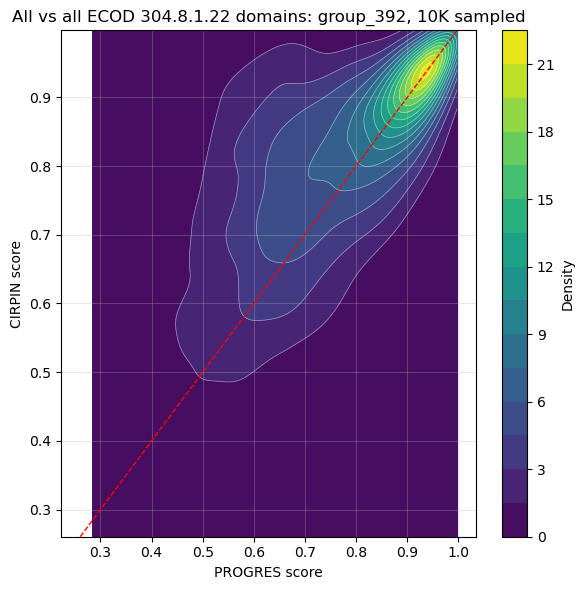

In [8]:
from scipy.stats import gaussian_kde
import numpy as np

plt.figure(figsize=(6, 6))

x = df_plot['progres'].values
y = df_plot['cirpin'].values

# Create 2D kernel density estimate
xy = np.vstack([x, y])
kde = gaussian_kde(xy)

# Build a regular grid
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
xx, yy = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(positions).reshape(xx.shape)

# Filled contour
cf = plt.contourf(xx, yy, zz, levels=15, cmap='viridis')
plt.colorbar(cf, label='Density')

# Contour lines on top
plt.contour(xx, yy, zz, levels=15, colors='white', linewidths=0.5, alpha=0.5)

plt.xlabel('PROGRES score')
plt.ylabel('CIRPIN score')
plt.title(f'All vs all ECOD {ecod_name} domains: group_{group_num}, 10K sampled')
plt.grid(True, alpha=0.3)

# Identity line
mn = min(x_min, y_min)
mx = max(x_max, y_max)
plt.plot([mn, mx], [mn, mx], '--', color='red', linewidth=1)

plt.tight_layout()
plt.show()

In [ ]:
# Get ecod name
group_file = f'/home/gridsan/akolodziej/ECOD_2/h_groups/group_{group_num}.txt'

with open(group_file, "r") as f:
    first_line = f.readline().strip()

In [ ]:
first_line

In [ ]:
first_line.split('\t')[3]